In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.cloud import bigquery
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

PROJECT_ID = "my-project-learning-496207"
DATASET    = "ecommerce_marts"
KEY_FILE   = "../credentials/gcp-key.json"

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = KEY_FILE

client = bigquery.Client(project=PROJECT_ID)

engine = create_engine(
    f"bigquery://{PROJECT_ID}/{DATASET}",
    credentials_path=KEY_FILE
)

print("Connected successfully!")

Connected successfully!


In [2]:
# Cell 2 — Helper function
def run_query(sql):
    """Run a SQL query and return a pandas DataFrame."""
    return pd.read_sql(sql, engine)

# Set chart style globally
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

In [3]:
# Cell 3 — Monthly sales trends
monthly_sales = run_query("""
    SELECT
        FORMAT_DATE('%Y-%m', purchased_at)   AS month,
        COUNT(DISTINCT order_id)             AS total_orders,
        ROUND(SUM(item_price), 2)            AS total_revenue,
        ROUND(AVG(item_price), 2)            AS avg_order_value
    FROM `my-project-learning-496207.ecommerce_marts.fact_orders`
    WHERE purchased_at IS NOT NULL
    GROUP BY month
    ORDER BY month
""")

print(f"Shape: {monthly_sales.shape}")
print(monthly_sales.head())

/home/liuyx/Project/Project_modulus_2/.venv/lib/python3.13/site-packages/google/cloud/bigquery/client.py:613: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(


Shape: (24, 4)
     month  total_orders  total_revenue  avg_order_value
0  2016-09             3         267.36            44.56
1  2016-10           308       49507.66           136.38
2  2016-12             1          10.90            10.90
3  2017-01           789      120312.87           125.98
4  2017-02          1733      247303.02           126.76


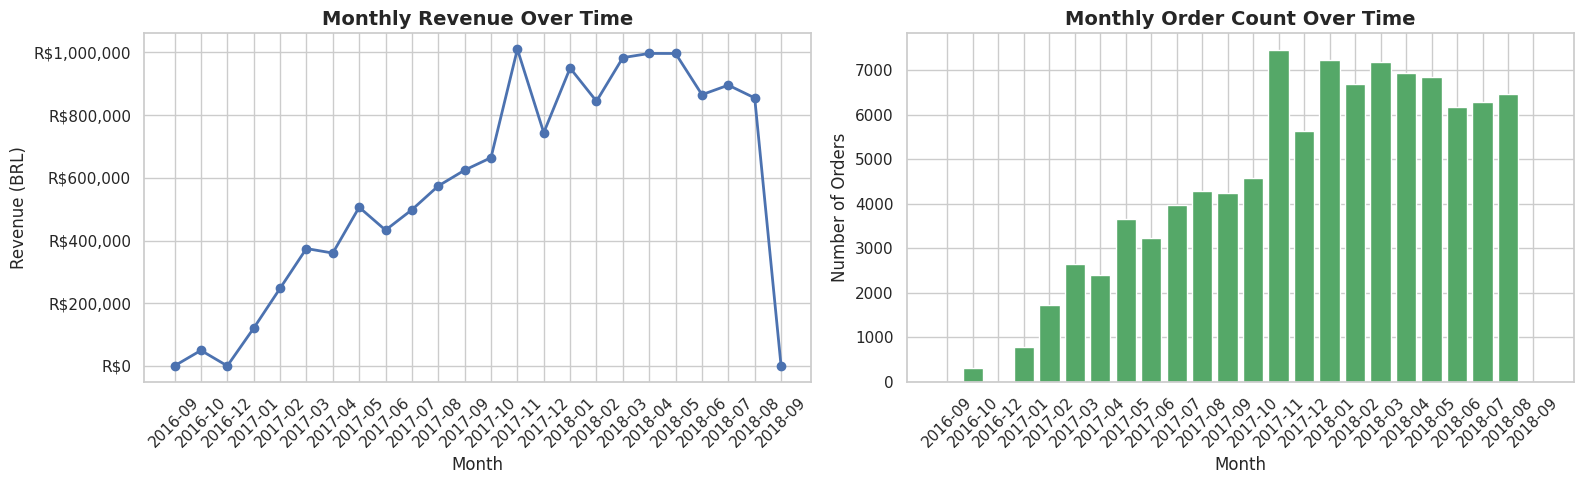

Chart saved to docs/monthly_sales_trend.png


In [4]:
# Cell 4 — Plot monthly revenue
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Revenue trend
axes[0].plot(
    monthly_sales["month"],
    monthly_sales["total_revenue"],
    marker="o", linewidth=2, color="#4C72B0"
)
axes[0].set_title("Monthly Revenue Over Time")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Revenue (BRL)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}")
)

# Order count trend
axes[1].bar(
    monthly_sales["month"],
    monthly_sales["total_orders"],
    color="#55A868"
)
axes[1].set_title("Monthly Order Count Over Time")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of Orders")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../docs/monthly_sales_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to docs/monthly_sales_trend.png")

In [5]:
# Cell 5 — Top selling products by category
top_categories = run_query("""
    SELECT
        p.category_english,
        COUNT(DISTINCT f.order_id)      AS total_orders,
        ROUND(SUM(f.item_price), 2)     AS total_revenue,
        ROUND(AVG(f.item_price), 2)     AS avg_price
    FROM `my-project-learning-496207.ecommerce_marts.fact_orders` f
    LEFT JOIN `my-project-learning-496207.ecommerce_marts.dim_products` p
        ON f.product_key = p.product_key
    WHERE p.category_english IS NOT NULL
    GROUP BY p.category_english
    ORDER BY total_revenue DESC
    LIMIT 10
""")

print(top_categories)

        category_english  total_orders  total_revenue  avg_price
0          health_beauty          8836     1258681.34     130.16
1          watches_gifts          5624     1205005.68     201.14
2         bed_bath_table          9417     1036988.68      93.30
3         sports_leisure          7720      988048.97     114.34
4  computers_accessories          6689      911954.32     116.51
5        furniture_decor          6449      729762.49      87.56
6             cool_stuff          3632      635290.85     167.36
7             housewares          5884      632248.66      90.79
8                   auto          3897      592720.11     139.96
9           garden_tools          3518      485256.46     111.63


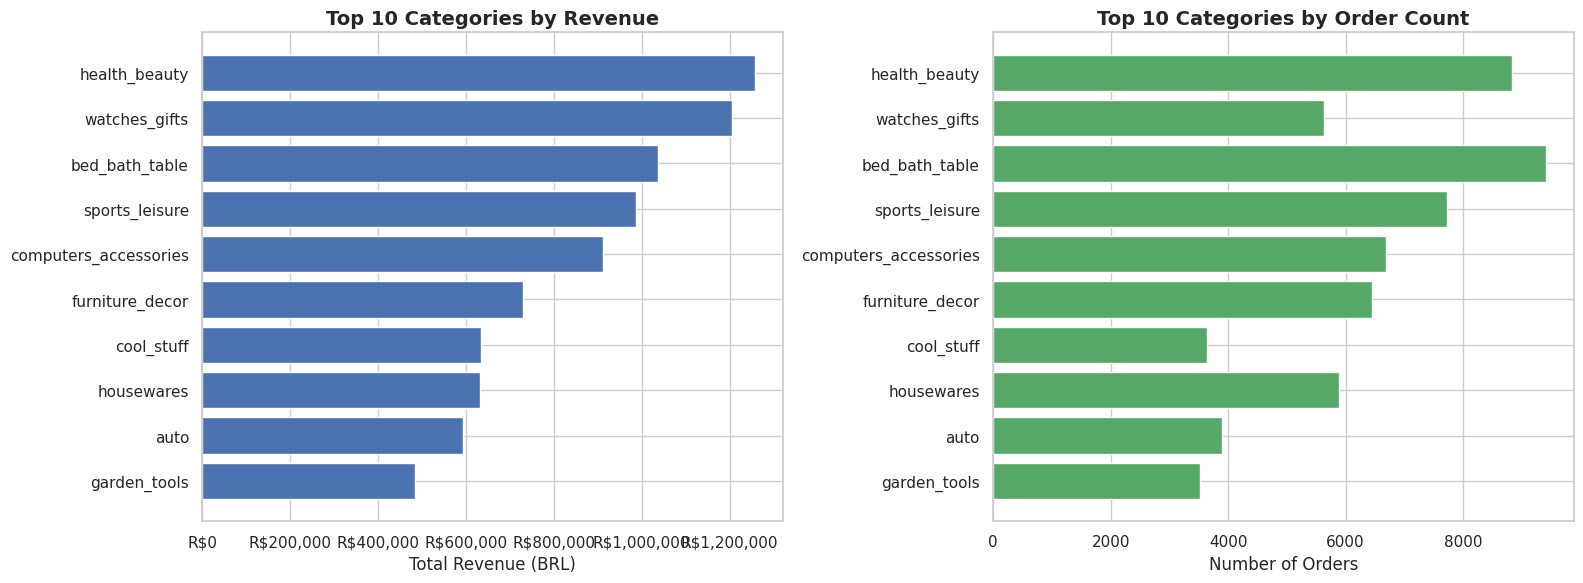

Chart saved to docs/top_categories.png


In [6]:
# Cell 6 — Plot top categories
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 by revenue
axes[0].barh(
    top_categories["category_english"][::-1],
    top_categories["total_revenue"][::-1],
    color="#4C72B0"
)
axes[0].set_title("Top 10 Categories by Revenue")
axes[0].set_xlabel("Total Revenue (BRL)")
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}")
)

# Top 10 by order count
axes[1].barh(
    top_categories["category_english"][::-1],
    top_categories["total_orders"][::-1],
    color="#55A868"
)
axes[1].set_title("Top 10 Categories by Order Count")
axes[1].set_xlabel("Number of Orders")

plt.tight_layout()
plt.savefig("../docs/top_categories.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to docs/top_categories.png")

In [7]:
# Cell 7 — Calculate RFM metrics
rfm = run_query("""
    WITH rfm_base AS (
        SELECT
            f.customer_key,
            MAX(f.purchased_at)                     AS last_purchase_date,
            COUNT(DISTINCT f.order_id)              AS frequency,
            ROUND(SUM(f.item_price), 2)             AS monetary
        FROM `my-project-learning-496207.ecommerce_marts.fact_orders` f
        GROUP BY f.customer_key
    )
    SELECT
        customer_key,
        DATE_DIFF(
            CURRENT_DATE(),
            DATE(last_purchase_date),
            DAY
        )                                           AS recency_days,
        frequency,
        monetary
    FROM rfm_base
""")

print(f"Total customers: {len(rfm):,}")
print(rfm.describe())

Total customers: 98,666
       recency_days  frequency      monetary
count  98666.000000    98666.0  98666.000000
mean    3073.716062        1.0    137.754076
std      153.392938        0.0    210.645145
min     2828.000000        1.0      0.850000
25%     2950.000000        1.0     45.900000
50%     3055.000000        1.0     86.900000
75%     3184.000000        1.0    149.900000
max     3557.000000        1.0  13440.000000


In [8]:
# Cell 8 — Score and segment customers
# Score each metric 1-4 using quartiles
rfm["R_score"] = pd.qcut(rfm["recency_days"],  q=4, labels=[4, 3, 2, 1])
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), q=4, labels=[1, 2, 3, 4])
rfm["M_score"] = pd.qcut(rfm["monetary"],      q=4, labels=[1, 2, 3, 4])

rfm["RFM_score"] = (
    rfm["R_score"].astype(int) +
    rfm["F_score"].astype(int) +
    rfm["M_score"].astype(int)
)

# Assign segments based on score
def assign_segment(score):
    if score >= 10:
        return "Champions"
    elif score >= 8:
        return "Loyal Customers"
    elif score >= 6:
        return "Potential Loyalists"
    elif score >= 4:
        return "At Risk"
    else:
        return "Lost"

rfm["segment"] = rfm["RFM_score"].apply(assign_segment)

print(rfm["segment"].value_counts())

segment
Loyal Customers        36011
Potential Loyalists    34626
Champions              14280
At Risk                12398
Lost                    1351
Name: count, dtype: int64


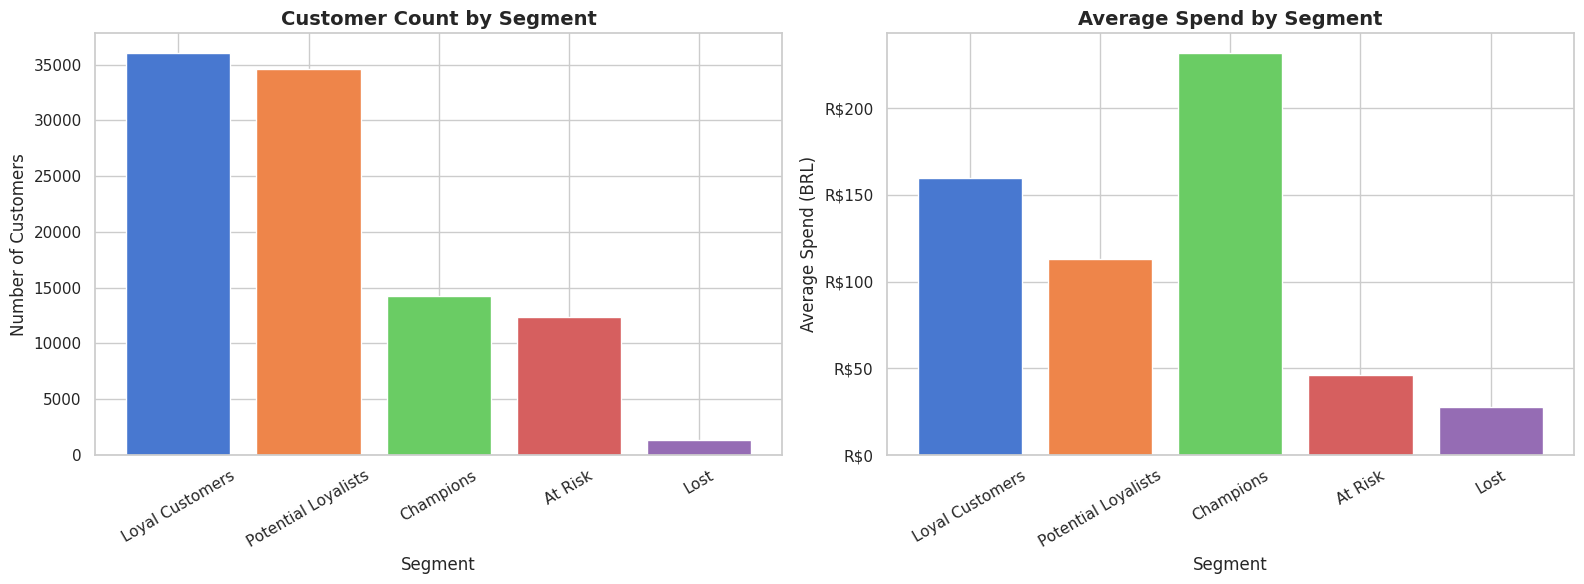

Chart saved to docs/customer_segments.png


In [9]:
# Cell 9 — Plot customer segments
segment_summary = (
    rfm.groupby("segment")
    .agg(
        customer_count=("customer_key", "count"),
        avg_monetary=("monetary", "mean"),
        avg_frequency=("frequency", "mean")
    )
    .reset_index()
    .sort_values("customer_count", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Customer count per segment
axes[0].bar(
    segment_summary["segment"],
    segment_summary["customer_count"],
    color=sns.color_palette("muted", len(segment_summary))
)
axes[0].set_title("Customer Count by Segment")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis="x", rotation=30)

# Average spend per segment
axes[1].bar(
    segment_summary["segment"],
    segment_summary["avg_monetary"],
    color=sns.color_palette("muted", len(segment_summary))
)
axes[1].set_title("Average Spend by Segment")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Average Spend (BRL)")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}")
)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../docs/customer_segments.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to docs/customer_segments.png")

In [10]:
# Cell 10 — Top sellers by revenue
seller_perf = run_query("""
    SELECT
        s.seller_key,
        s.city,
        s.state,
        s.region,
        COUNT(DISTINCT f.order_id)      AS total_orders,
        ROUND(SUM(f.item_price), 2)     AS total_revenue,
        ROUND(AVG(f.review_score), 2)   AS avg_review_score
    FROM `my-project-learning-496207.ecommerce_marts.fact_orders` f
    LEFT JOIN `my-project-learning-496207.ecommerce_marts.dim_sellers` s
        ON f.seller_key = s.seller_key
    GROUP BY s.seller_key, s.city, s.state, s.region
    ORDER BY total_revenue DESC
    LIMIT 10
""")

print(seller_perf)

                         seller_key              city state     region  \
0  4869f7a5dfa277a7dca6462dcf3b52b2           Guariba    SP  Southeast   
1  53243585a1d6dc2643021fd1853d8905  Lauro De Freitas    BA  Northeast   
2  4a3ca9315b744ce9f8e9374361493884          Ibitinga    SP  Southeast   
3  fa1c13f2614d7b5c4749cbc52fecda94            Sumare    SP  Southeast   
4  7c67e1448b00f6e969d365cea6b010ab   Itaquaquecetuba    SP  Southeast   
5  7e93a43ef30c4f03f38b393420bc753a           Barueri    SP  Southeast   
6  da8622b14eb17ae2831f4ac5b9dab84a        Piracicaba    SP  Southeast   
7  7a67c85e85bb2ce8582c35f2203ad736         Sao Paulo    SP  Southeast   
8  1025f0e2d44d7041d6cf58b6550e0bfa         Sao Paulo    SP  Southeast   
9  955fee9216a65b617aa5c0531780ce60         Sao Paulo    SP  Southeast   

   total_orders  total_revenue  avg_review_score  
0          1132      229472.63              4.12  
1           358      222776.05              4.08  
2          1806      200472.92  

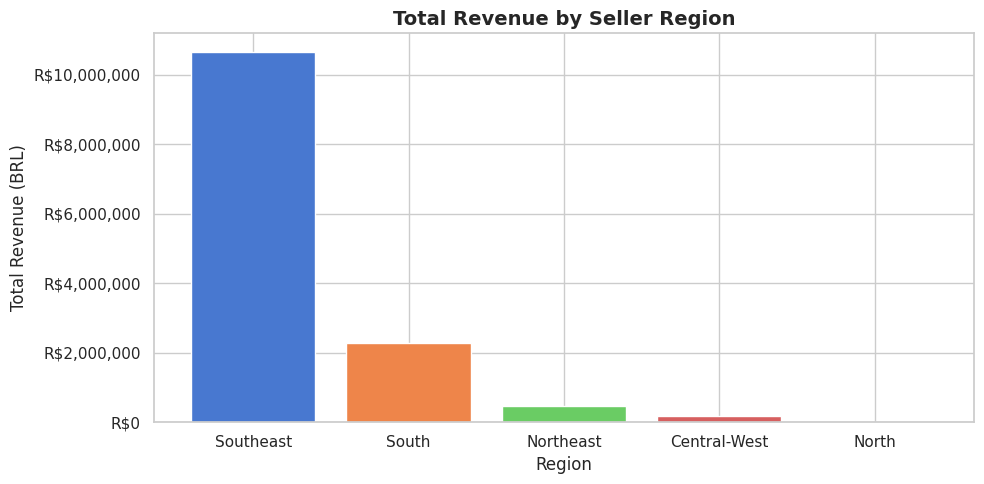

In [11]:
# Cell 11 — Revenue by region
region_revenue = run_query("""
    SELECT
        s.region,
        ROUND(SUM(f.item_price), 2)     AS total_revenue,
        COUNT(DISTINCT f.order_id)      AS total_orders,
        COUNT(DISTINCT s.seller_key)    AS total_sellers
    FROM `my-project-learning-496207.ecommerce_marts.fact_orders` f
    LEFT JOIN `my-project-learning-496207.ecommerce_marts.dim_sellers` s
        ON f.seller_key = s.seller_key
    WHERE s.region IS NOT NULL
    GROUP BY s.region
    ORDER BY total_revenue DESC
""")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    region_revenue["region"],
    region_revenue["total_revenue"],
    color=sns.color_palette("muted", len(region_revenue))
)
ax.set_title("Total Revenue by Seller Region")
ax.set_xlabel("Region")
ax.set_ylabel("Total Revenue (BRL)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}")
)
plt.tight_layout()
plt.savefig("../docs/revenue_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Cell 12 — Executive summary metrics
summary = run_query("""
    SELECT
        COUNT(DISTINCT order_id)            AS total_orders,
        COUNT(DISTINCT customer_key)        AS total_customers,
        COUNT(DISTINCT seller_key)          AS total_sellers,
        COUNT(DISTINCT product_key)         AS total_products,
        ROUND(SUM(item_price), 2)           AS total_revenue,
        ROUND(AVG(item_price), 2)           AS avg_order_value,
        ROUND(AVG(review_score), 2)         AS avg_review_score
    FROM `my-project-learning-496207.ecommerce_marts.fact_orders`
""")

print("=" * 50)
print("EXECUTIVE SUMMARY METRICS")
print("=" * 50)
for col in summary.columns:
    print(f"{col.replace('_', ' ').title():<25}: {summary[col].values[0]:>15,}")

EXECUTIVE SUMMARY METRICS
Total Orders             :          98,666
Total Customers          :          98,666
Total Sellers            :           3,095
Total Products           :          32,951
Total Revenue            :    13,591,643.7
Avg Order Value          :          120.65
Avg Review Score         :            4.03
